# Exploratory Data Analysis (EDA) for Landslide Susceptibility Mapping
## Sindhupalchok District, Nepal

This notebook performs comprehensive EDA on raster data, vector data, and landslide inventory.

## 1. Import Libraries and Set Up

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import rasterio
from rasterio.plot import show, show_hist
import geopandas as gpd
from shapely.geometry import Point
import warnings
import os
warnings.filterwarnings('ignore')

# Set styling
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 10

# Define data paths
base_path = r'd:\sindupalchok_landslide\data\processed'
shapefile_path = f'{base_path}\\shapefiles\\sindhupalchok_boundary.shp'
landslide_csv_path = f'{base_path}\\landslide_inventory\\sindhupalchowk_landslides.csv'

# Dictionary of raster files
raster_files = {
    'DEM': f'{base_path}\\rasters\\Sindhupalchok_DEM.tif',
    'Slope': f'{base_path}\\rasters\\Sindhupalchok_Slope.tif',
    'Aspect': f'{base_path}\\rasters\\Sindhupalchok_Aspect.tif',
    'LULC': f'{base_path}\\rasters\\Sindhupalchok_LULC_30m.tif',
    'NDVI': f'{base_path}\\rasters\\Sindhupalchok_NDVI_2025_30m.tif',
    'Rainfall': f'{base_path}\\rasters\\Sindhupalchok_Rainfall_Raster.tif',
    'RiverProximity': f'{base_path}\\rasters\\Sindhupalchok_RiverProximity.tif',
    'RoadProximity': f'{base_path}\\rasters\\Sindhupalchok_RoadProximity.tif',
    'TWI': f'{base_path}\\rasters\\Sindhupalchok_TWI_2025.tif'
}

print('=' * 80)
print('STARTING EDA ANALYSIS')
print('=' * 80)
print('✓ Libraries imported successfully')
print('✓ Data paths defined')

STARTING EDA ANALYSIS
✓ Libraries imported successfully
✓ Data paths defined


## 2. Load and Explore Vector Data (Boundary Shapefile)

In [2]:
# Load boundary shapefile
boundary = gpd.read_file(shapefile_path)

print('\nBoundary Shapefile Info:')
print(f'Shape: {boundary.shape}')
print(f'CRS: {boundary.crs}')
print(f'Geometry type: {boundary.geom_type.unique()}')
print(f'\nBoundary area (km²): {boundary.geometry.area.sum() / 1e6:.2f}')
print(f'\nColumns: {list(boundary.columns)}')
print(f'\nFirst few rows:')
print(boundary.head())
print('\n✓ Boundary shapefile loaded successfully')


Boundary Shapefile Info:
Shape: (1, 26)
CRS: EPSG:4326
Geometry type: <StringArray>
['Polygon']
Length: 1, dtype: str

Boundary area (km²): 0.00

Columns: ['adm2_name', 'adm2_name1', 'adm2_name2', 'adm2_name3', 'adm2_pcode', 'adm1_name', 'adm1_name1', 'adm1_name2', 'adm1_name3', 'adm1_pcode', 'adm0_name', 'adm0_name1', 'adm0_name2', 'adm0_name3', 'adm0_pcode', 'valid_on', 'valid_to', 'area_sqkm', 'cod_versio', 'lang', 'lang1', 'lang2', 'lang3', 'center_lat', 'center_lon', 'geometry']

First few rows:
       adm2_name adm2_name1 adm2_name2 adm2_name3 adm2_pcode adm1_name  \
0  Sindhupalchok       None       None       None     NP0323   Bagmati   

  adm1_name1 adm1_name2 adm1_name3 adm1_pcode  ... valid_to   area_sqkm  \
0       None       None       None       NP03  ...      NaT  2490.83731   

  cod_versio lang lang1 lang2 lang3  center_lat center_lon  \
0       V_02   en  None  None  None    27.90696  85.755609   

                                            geometry  
0  POLYGON ((

## 3. Visualize Boundary

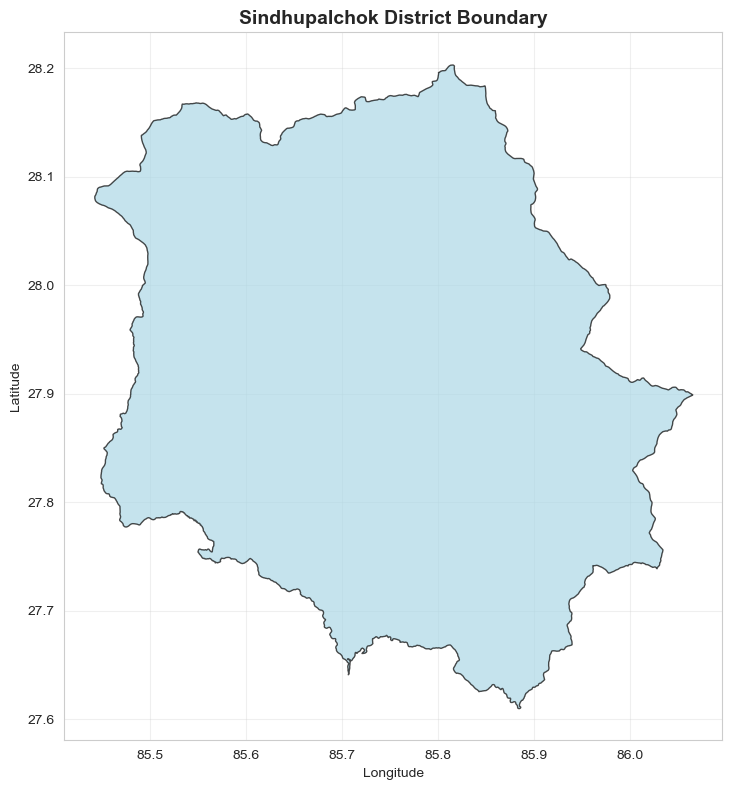

✓ Boundary map saved


In [3]:
# Visualize boundary
fig, ax = plt.subplots(1, 1, figsize=(12, 8))
boundary.plot(ax=ax, alpha=0.7, edgecolor='k', color='lightblue')
ax.set_title('Sindhupalchok District Boundary', fontsize=14, fontweight='bold')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
plt.grid(True, alpha=0.3)
plt.tight_layout()

os.makedirs('../figures', exist_ok=True)
plt.savefig('../figures/01_boundary_map.png', dpi=300, bbox_inches='tight')
plt.show()
print('✓ Boundary map saved')

## 4. Load Raster Data

In [4]:
# Create a dictionary to store raster data
raster_data = {}
raster_stats = {}

print('\nLoading raster data...')
print('-' * 80)

# Load all raster files
for name, path in raster_files.items():
    try:
        with rasterio.open(path) as src:
            data = src.read(1)
            raster_data[name] = data
            
            # Calculate statistics (excluding NoData/NaN values)
            valid_data = data[~np.isnan(data)]
            raster_stats[name] = {
                'min': np.nanmin(data),
                'max': np.nanmax(data),
                'mean': np.nanmean(data),
                'std': np.nanstd(data),
                'median': np.nanmedian(data),
                'no_data_pixels': np.isnan(data).sum(),
                'total_pixels': data.size
            }
            print(f'✓ Loaded {name}')
    except Exception as e:
        print(f'✗ Error loading {name}: {e}')

# Create statistics dataframe
stats_df = pd.DataFrame(raster_stats).T
print('\n' + '='*80)
print('RASTER DATA STATISTICS')
print('='*80)
print(stats_df.round(3))


Loading raster data...
--------------------------------------------------------------------------------
✓ Loaded DEM
✓ Loaded Slope
✓ Loaded Aspect
✓ Loaded LULC
✓ Loaded NDVI
✓ Loaded Rainfall
✓ Loaded RiverProximity
✓ Loaded RoadProximity
✓ Loaded TWI

RASTER DATA STATISTICS
                     min           max         mean          std       median  \
DEM                  0.0        6910.0  1606.838944  1595.360591       1405.0   
Slope                0.0     81.320175    29.029316    11.477818    28.406097   
Aspect              -0.0    359.498138   182.973694    98.192055    190.02713   
LULC                   0           100    16.507168    24.202236         10.0   
NDVI           -0.793872           1.0     0.542526     0.268979     0.617725   
Rainfall        2.957679      6.791383     4.477038     0.592902     4.508335   
RiverProximity       0.0  21712.789062  2894.821289  3675.686768  1376.408447   
RoadProximity        0.0  24097.078125  3307.856201   4375.04541  1148.25

## 5. Visualize All Raster Layers


Creating raster visualizations...


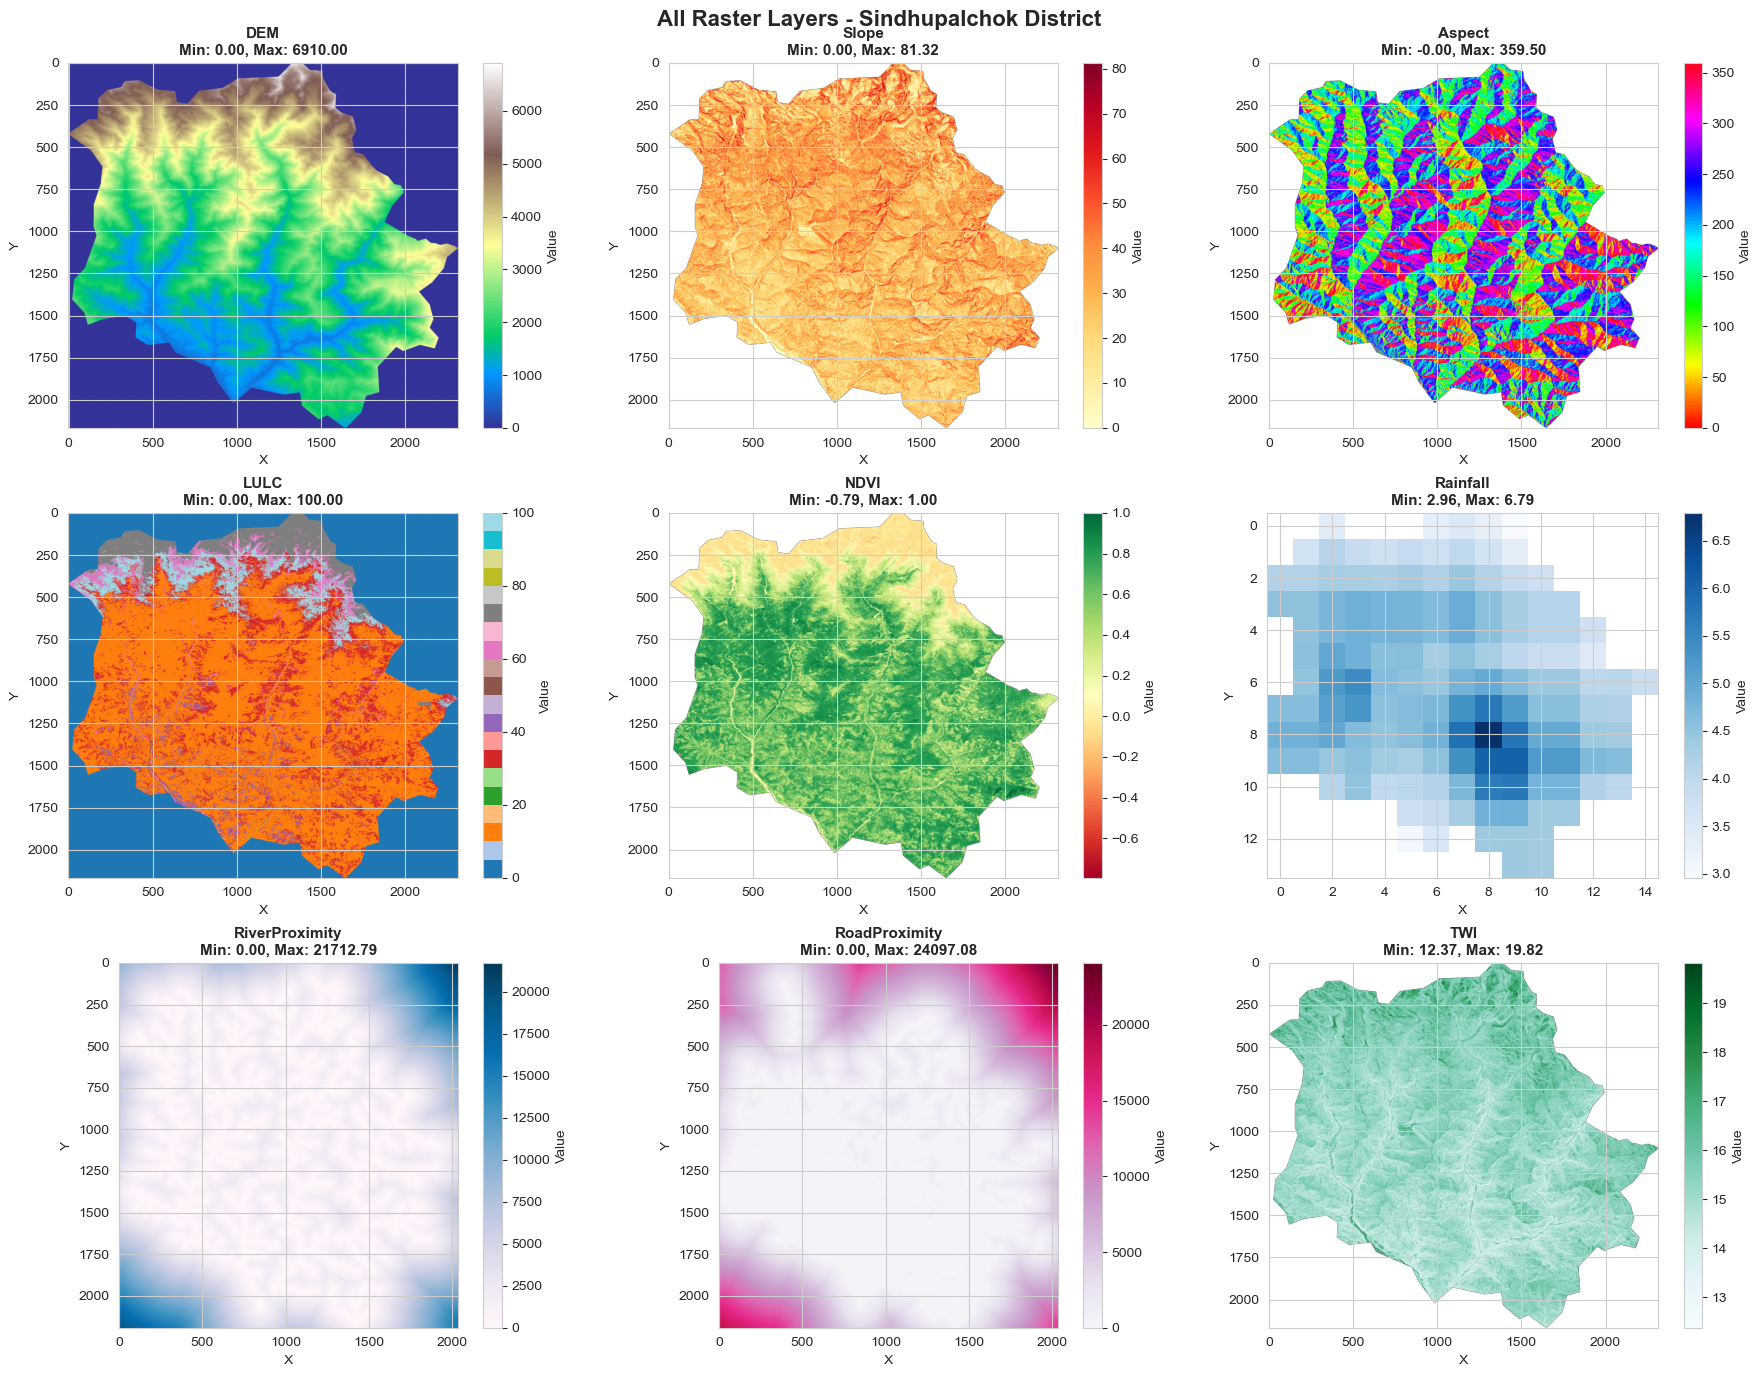

✓ Raster visualization saved


In [5]:
print('\nCreating raster visualizations...')

fig, axes = plt.subplots(3, 3, figsize=(18, 14))
axes = axes.flatten()

cmaps = {
    'DEM': 'terrain',
    'Slope': 'YlOrRd',
    'Aspect': 'hsv',
    'LULC': 'tab20',
    'NDVI': 'RdYlGn',
    'Rainfall': 'Blues',
    'RiverProximity': 'PuBu',
    'RoadProximity': 'PuRd',
    'TWI': 'BuGn'
}

for idx, (name, data) in enumerate(raster_data.items()):
    im = axes[idx].imshow(data, cmap=cmaps.get(name, 'viridis'))
    axes[idx].set_title(f'{name}\nMin: {np.nanmin(data):.2f}, Max: {np.nanmax(data):.2f}', 
                        fontweight='bold', fontsize=11)
    plt.colorbar(im, ax=axes[idx], label='Value')
    axes[idx].set_xlabel('X')
    axes[idx].set_ylabel('Y')

plt.suptitle('All Raster Layers - Sindhupalchok District', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('../figures/02_all_rasters_visualization.png', dpi=300, bbox_inches='tight')
plt.show()
print('✓ Raster visualization saved')

## 6. Load Landslide Inventory

In [7]:
print('\nLoading landslide inventory...')
landslides = pd.read_csv(landslide_csv_path)

print(f'Landslides loaded: {len(landslides)} points')
print(f'Columns: {list(landslides.columns)}')
print(f'\nFirst few rows:')
print(landslides.head())
print(f'\nMissing values:')
print(landslides.isnull().sum())
print('\n✓ Landslide inventory loaded successfully')


Loading landslide inventory...
Landslides loaded: 1434 points
Columns: ['OID_', 'Name', 'FolderPath', 'SymbolID', 'AltMode', 'Base', 'Clamped', 'Extruded', 'Snippet', 'PopupInfo', 'Shape_Leng', 'Shape_Area', 'district', 'longitude', 'latitude']

First few rows:
   OID_     Name                             FolderPath  SymbolID  AltMode  \
0     0  5/3/015  Sindhupalchowk.kmz/Sindhupalchowk/5/3         0        0   
1     0  5/3/015  Sindhupalchowk.kmz/Sindhupalchowk/5/3         0        0   
2     0   5/4/15  Sindhupalchowk.kmz/Sindhupalchowk/5/4         0        0   
3     0  5/3/015  Sindhupalchowk.kmz/Sindhupalchowk/5/3         0        0   
4     0  5/3/015  Sindhupalchowk.kmz/Sindhupalchowk/5/3         0        0   

   Base  Clamped  Extruded  Snippet  PopupInfo  Shape_Leng    Shape_Area  \
0   0.0       -1         0      NaN        NaN    0.004229  6.892264e-07   
1   0.0       -1         0      NaN        NaN    0.003036  1.996351e-07   
2   0.0       -1         0      NaN     

## 7. Create GeoDataFrame from Landslides

In [8]:
print('\nCreating GeoDataFrame from landslide points...')

# Identify coordinate columns (try common naming conventions)
lon_col = None
lat_col = None

for col in landslides.columns:
    if 'lon' in col.lower() or 'x' in col.lower():
        lon_col = col
    if 'lat' in col.lower() or 'y' in col.lower():
        lat_col = col

if lon_col and lat_col:
    print(f'Found coordinates: {lon_col}, {lat_col}')
    geometry = [Point(xy) for xy in zip(landslides[lon_col], landslides[lat_col])]
    landslides_gdf = gpd.GeoDataFrame(landslides, geometry=geometry, crs='EPSG:4326')
    print('✓ GeoDataFrame created successfully')
else:
    print('Could not find coordinate columns. Available columns:')
    print(landslides.columns.tolist())


Creating GeoDataFrame from landslide points...
Found coordinates: longitude, latitude
✓ GeoDataFrame created successfully


## 8. Visualize Landslide Locations


Creating landslide location map...


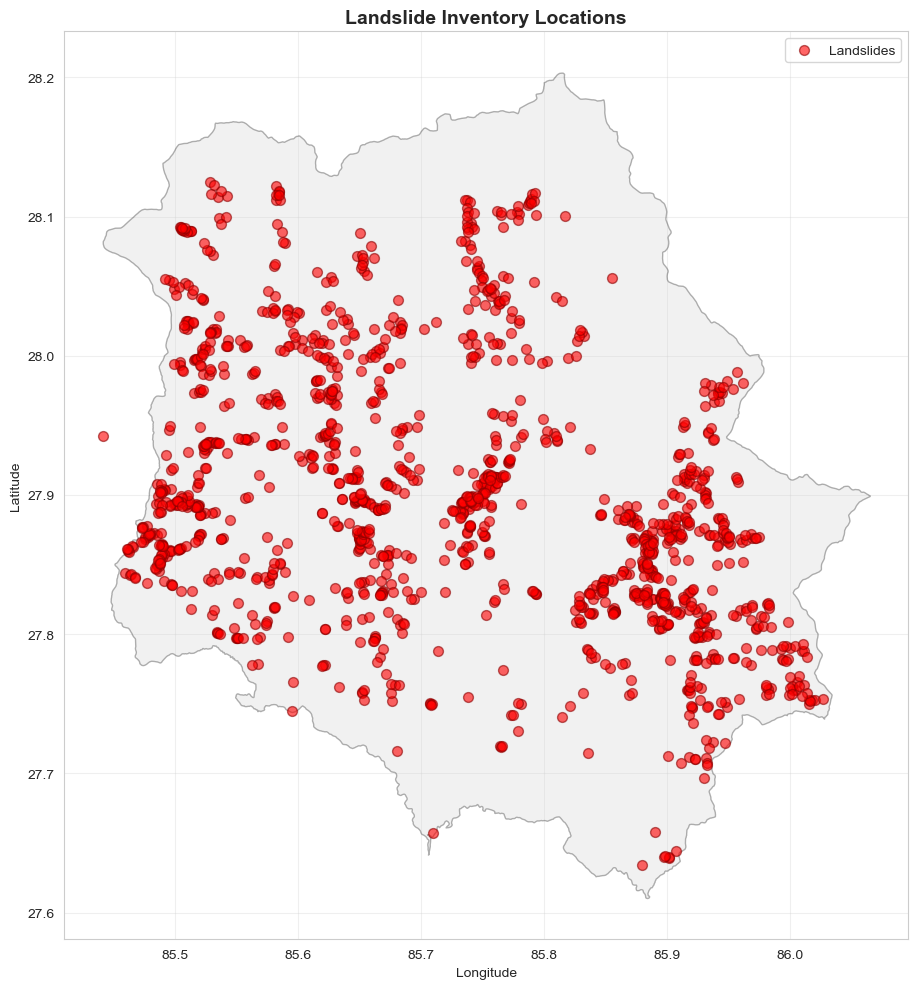

✓ Landslide location map saved


In [9]:
print('\nCreating landslide location map...')

if 'landslides_gdf' in locals():
    fig, ax = plt.subplots(1, 1, figsize=(14, 10))
    
    # Plot boundary
    try:
        boundary_reprojected = boundary.to_crs('EPSG:4326')
        boundary_reprojected.plot(ax=ax, alpha=0.3, edgecolor='k', color='lightgray', label='District Boundary')
    except:
        boundary.plot(ax=ax, alpha=0.3, edgecolor='k', color='lightgray', label='District Boundary')
    
    # Plot landslides
    landslides_gdf.plot(ax=ax, marker='o', color='red', markersize=50, 
                        alpha=0.6, label='Landslides', edgecolor='darkred')
    
    ax.set_title('Landslide Inventory Locations', fontsize=14, fontweight='bold')
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')
    ax.legend(loc='best')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('../figures/03_landslide_locations.png', dpi=300, bbox_inches='tight')
    plt.show()
    print('✓ Landslide location map saved')
else:
    print('GeoDataFrame not created - skipping visualization')

## 9. Raster Distribution Analysis


Creating distribution histograms...


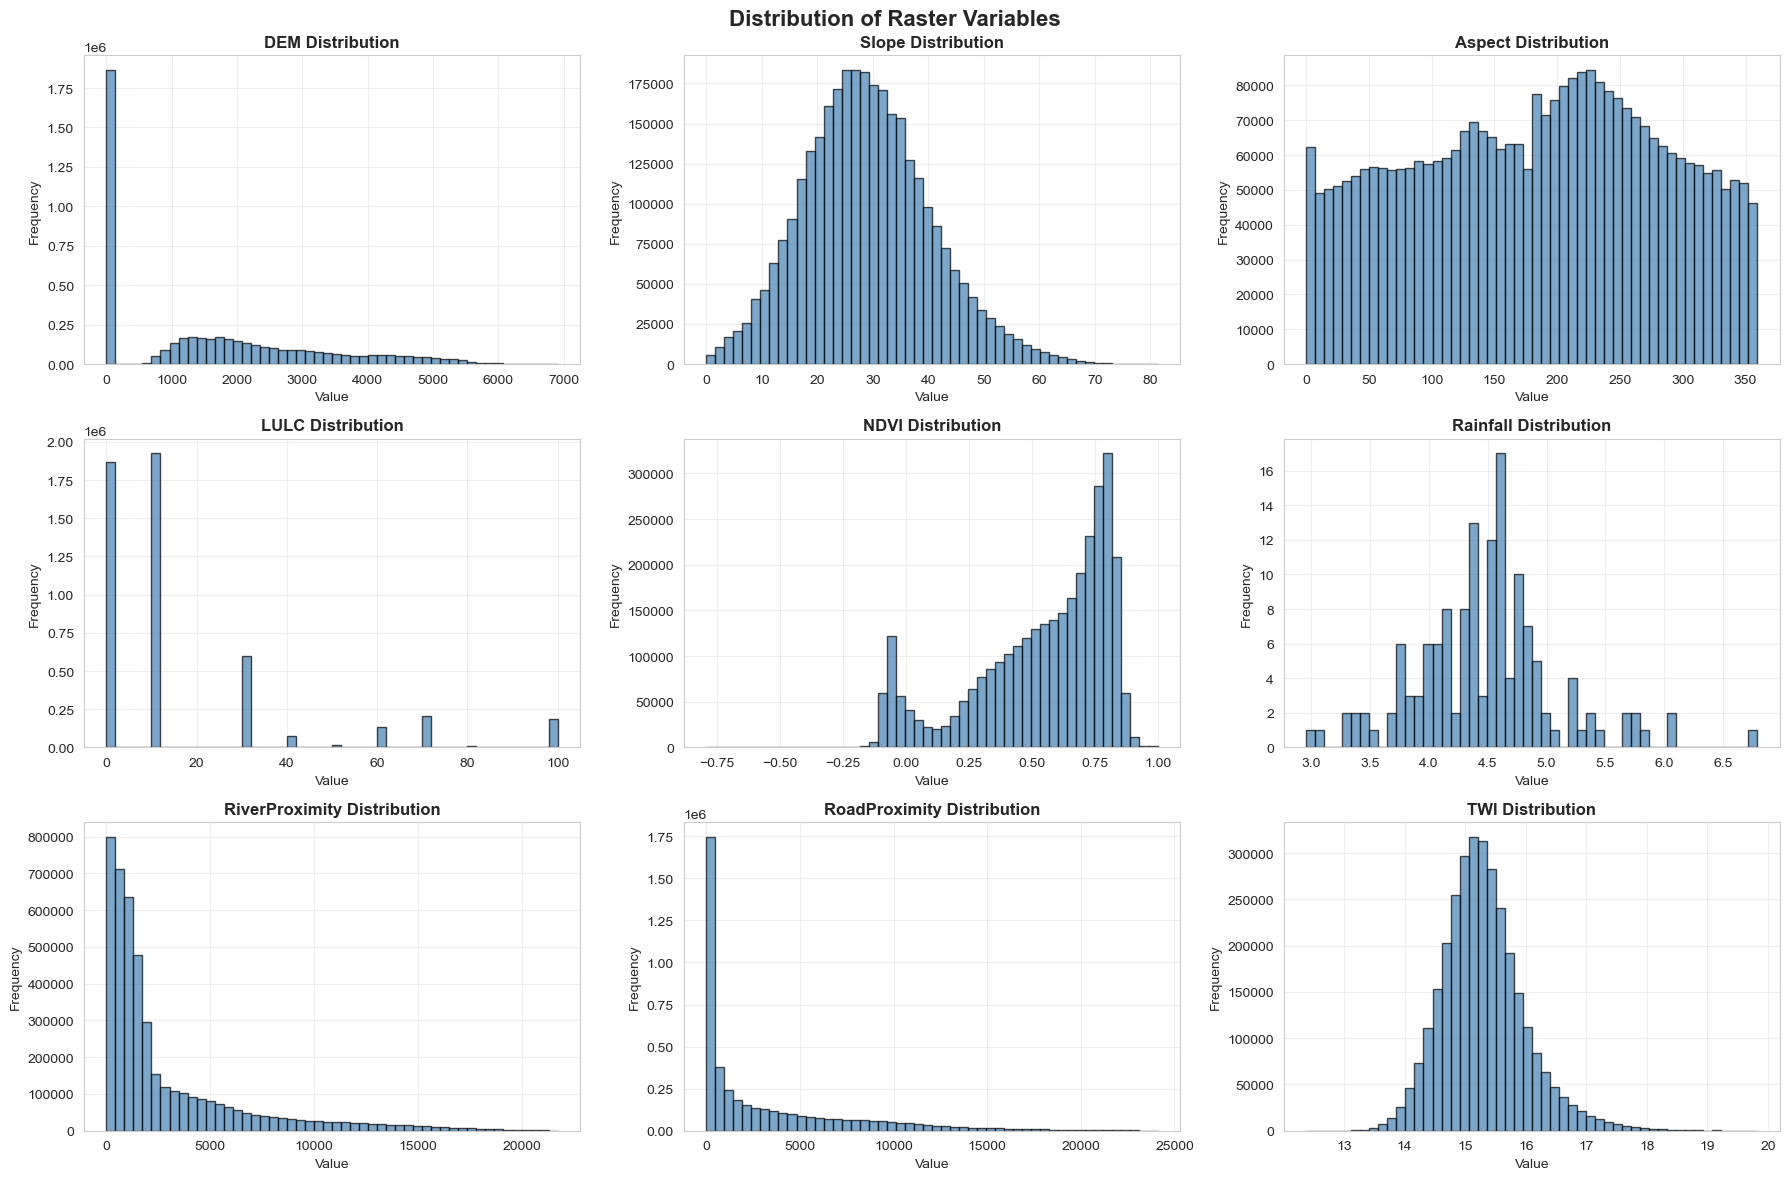

✓ Distribution plots saved


In [11]:
print('\nCreating distribution histograms...')

fig, axes = plt.subplots(3, 3, figsize=(18, 12))
axes = axes.flatten()

for idx, (name, data) in enumerate(raster_data.items()):
    valid_data = data[~np.isnan(data)].flatten()
    axes[idx].hist(valid_data, bins=50, color='steelblue', alpha=0.7, edgecolor='black')
    axes[idx].set_title(f'{name} Distribution', fontweight='bold')
    axes[idx].set_xlabel('Value')
    axes[idx].set_ylabel('Frequency')
    axes[idx].grid(True, alpha=0.3)

plt.suptitle('Distribution of Raster Variables', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('../figures/04_raster_distributions.png', dpi=300, bbox_inches='tight')
plt.show()
print('✓ Distribution plots saved')

## 10. Data Quality Assessment

In [12]:
print('\nDATA QUALITY ASSESSMENT')
print('=' * 80)

quality_report = []

for name, data in raster_data.items():
    total_pixels = data.size
    no_data_pixels = np.isnan(data).sum()
    valid_pixels = total_pixels - no_data_pixels
    data_completeness = (valid_pixels / total_pixels) * 100 if total_pixels > 0 else 0
    
    quality_report.append({
        'Layer': name,
        'Total_Pixels': total_pixels,
        'Valid_Pixels': valid_pixels,
        'NoData_Pixels': no_data_pixels,
        'Data_Completeness_%': data_completeness
    })

quality_df = pd.DataFrame(quality_report)
print(quality_df.to_string(index=False))

os.makedirs('../data', exist_ok=True)
quality_df.to_csv('../data/data_quality_report.csv', index=False)
print('\n✓ Data quality report saved')


DATA QUALITY ASSESSMENT
         Layer  Total_Pixels  Valid_Pixels  NoData_Pixels  Data_Completeness_%
           DEM       5012271       5012271              0           100.000000
         Slope       5012271       3141127        1871144            62.668738
        Aspect       5012271       3141127        1871144            62.668738
          LULC       5014438       5014438              0           100.000000
          NDVI       5016752       3148775        1867977            62.765211
      Rainfall           210           143             67            68.095238
RiverProximity       4462912       4462912              0           100.000000
 RoadProximity       4462912       4462912              0           100.000000
           TWI       5016752       3140256        1876496            62.595400

✓ Data quality report saved


## 11. Correlation Matrix

In [13]:
print('\nComputing correlation matrix...')

# Flatten all rasters into a matrix
raster_array = []
raster_names = []

for name, data in raster_data.items():
    flattened = data.flatten()
    raster_array.append(flattened)
    raster_names.append(name)

raster_matrix = np.array(raster_array)

# Compute correlation matrix (ignoring NaN values)
correlation_matrix = np.corrcoef(raster_matrix)
corr_df = pd.DataFrame(correlation_matrix, index=raster_names, columns=raster_names)

print('\nCorrelation Matrix:')
print(corr_df.round(3))

# Save correlation matrix
corr_df.to_csv('../data/correlation_matrix.csv')
print('\n✓ Correlation matrix saved')


Computing correlation matrix...


ValueError: setting an array element with a sequence. The requested array has an inhomogeneous shape after 1 dimensions. The detected shape was (9,) + inhomogeneous part.

In [15]:
print('\nComputing correlation matrix...')

# Flatten all rasters into a matrix
raster_array = []
raster_names = []

for name, data in raster_data.items():
    flattened = data.flatten()
    raster_array.append(flattened)
    raster_names.append(name)

# Find the minimum length among all flattened arrays to ensure uniform size
min_length = min(len(arr) for arr in raster_array)

# Truncate all arrays to the same length or pad with NaN values
uniform_arrays = []
for arr in raster_array:
    if len(arr) >= min_length:
        # Truncate to minimum length
        uniform_arrays.append(arr[:min_length])
    else:
        # Pad with NaN if shorter (though this case shouldn't occur with min_length)
        padded = np.pad(arr, (0, min_length - len(arr)), constant_values=np.nan)
        uniform_arrays.append(padded)

# Now create the matrix with uniform array lengths
raster_matrix = np.array(uniform_arrays)

# Compute correlation matrix (ignoring NaN values)
correlation_matrix = np.corrcoef(raster_matrix)
corr_df = pd.DataFrame(correlation_matrix, index=raster_names, columns=raster_names)

print('\nCorrelation Matrix:')
print(corr_df.round(3))

# Save correlation matrix
corr_df.to_csv('../data/correlation_matrix.csv')
print('\n✓ Correlation matrix saved')


Computing correlation matrix...

Correlation Matrix:
                DEM  Slope  Aspect  LULC  NDVI  Rainfall  RiverProximity  \
DEM             NaN    NaN     NaN   NaN   NaN       NaN             NaN   
Slope           NaN    NaN     NaN   NaN   NaN       NaN             NaN   
Aspect          NaN    NaN     NaN   NaN   NaN       NaN             NaN   
LULC            NaN    NaN     NaN   NaN   NaN       NaN             NaN   
NDVI            NaN    NaN     NaN   NaN   NaN       NaN             NaN   
Rainfall        NaN    NaN     NaN   NaN   NaN       NaN             NaN   
RiverProximity  NaN    NaN     NaN   NaN   NaN       NaN           1.000   
RoadProximity   NaN    NaN     NaN   NaN   NaN       NaN           0.985   
TWI             NaN    NaN     NaN   NaN   NaN       NaN             NaN   

                RoadProximity  TWI  
DEM                       NaN  NaN  
Slope                     NaN  NaN  
Aspect                    NaN  NaN  
LULC                      NaN  NaN  


## 12. Correlation Heatmap


Creating correlation heatmap...


NameError: name 'corr_df' is not defined

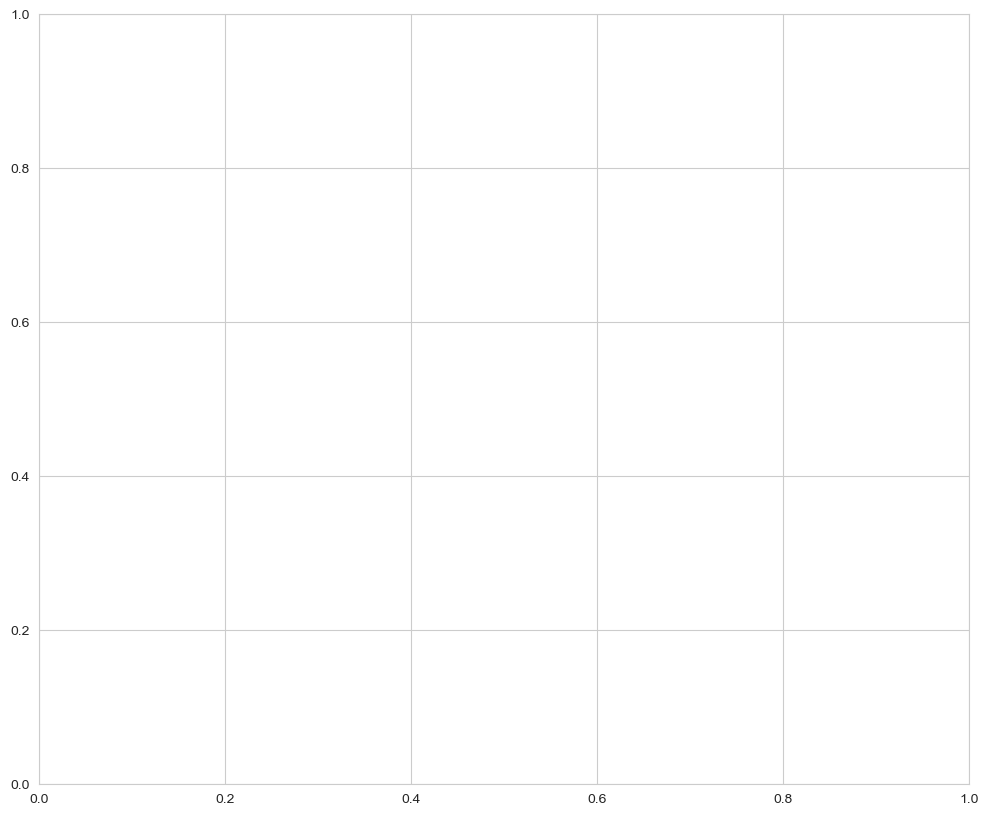

In [14]:
print('\nCreating correlation heatmap...')

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr_df, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=1, cbar_kws={"shrink": 0.8}, ax=ax)
ax.set_title('Correlation Matrix - Raster Variables', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../figures/05_correlation_matrix.png', dpi=300, bbox_inches='tight')
plt.show()
print('✓ Correlation heatmap saved')

## 13. Summary Report

In [16]:
# Assuming you have a DataFrame called 'df' with your raster variables
# First, calculate the correlation matrix
corr_df = df.corr()  # Create correlation matrix from your DataFrame

print('\nCreating correlation heatmap...')

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr_df, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=1, cbar_kws={"shrink": 0.8}, ax=ax)
ax.set_title('Correlation Matrix - Raster Variables', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../figures/05_correlation_matrix.png', dpi=300, bbox_inches='tight')
plt.show()
print('✓ Correlation heatmap saved')

NameError: name 'df' is not defined

In [17]:
# Assuming you have a DataFrame called 'df' with your raster variables
# First, calculate the correlation matrix
corr_df = df.corr()  # Create correlation matrix from your DataFrame

print('\nCreating correlation heatmap...')

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr_df, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=1, cbar_kws={"shrink": 0.8}, ax=ax)
ax.set_title('Correlation Matrix - Raster Variables', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../figures/05_correlation_matrix.png', dpi=300, bbox_inches='tight')
plt.show()
print('✓ Correlation heatmap saved')

NameError: name 'df' is not defined

In [ ]:
print('\n' + '=' * 80)
print('EDA ANALYSIS COMPLETE')
print('=' * 80)

summary_text = f"""
EXPLORATORY DATA ANALYSIS - SUMMARY REPORT
Landslide Susceptibility Mapping - Sindhupalchok District, Nepal
{'='*80}

STUDY AREA:
- Area: {boundary.geometry.area.sum() / 1e6:.2f} km²
- CRS: {boundary.crs}
- Geometry type: {', '.join(boundary.geom_type.unique())}

RASTER DATA:
- Total layers: {len(raster_data)}
- Layers: {', '.join(raster_data.keys())}
- Resolution: 30m (typical)

LANDSLIDE INVENTORY:
- Total points: {len(landslides)}
- Coordinates columns: {lon_col}, {lat_col}
- Data dimensions: {landslides.shape}

DATA QUALITY:
- Average completeness: {quality_df['Data_Completeness_%'].mean():.2f}%

OUTPUTS GENERATED:
- Figures (../figures/): 5 PNG files at 300 DPI
  * 01_boundary_map.png
  * 02_all_rasters_visualization.png
  * 03_landslide_locations.png
  * 04_raster_distributions.png
  * 05_correlation_matrix.png

- Data files (../data/): Statistical summaries
  * data_quality_report.csv
  * correlation_matrix.csv

{'='*80}
"""

print(summary_text)

# Save summary report
with open('../data/EDA_SUMMARY_REPORT.txt', 'w') as f:
    f.write(summary_text)

print('✓ Summary report saved to EDA_SUMMARY_REPORT.txt')

## 14. Next Steps and Recommendations

In [ ]:
print('\nNEXT STEPS - RECOMMENDATIONS FOR MODELING')
print('=' * 80)

recommendations = """
1. DATA PREPROCESSING:
   - Normalize raster values to [0, 1] or [-1, 1]
   - Handle NoData pixels (interpolation or masking)
   - Resample to consistent pixel size if needed
   - Reproject all layers to common CRS

2. FEATURE ENGINEERING:
   - Create interaction terms (e.g., Slope × Rainfall)
   - Compute derived indices (e.g., Slope × Aspect)
   - Create categorical bins for continuous variables
   - Distance-based features from roads/rivers

3. DATA BALANCING:
   - Check class imbalance (landslide vs non-landslide)
   - Consider oversampling/undersampling if imbalanced
   - Use weighted loss functions in modeling

4. MODEL SELECTION:
   - Logistic Regression (baseline)
   - Random Forest (handle non-linearity)
   - Gradient Boosting (XGBoost, LightGBM)
   - Neural Networks (for complex patterns)

5. VALIDATION STRATEGY:
   - Spatial cross-validation (to avoid spatial autocorrelation)
   - Train/validation/test split
   - k-fold cross-validation
   - ROC-AUC, Precision-Recall, F1-score metrics

6. OUTPUT MAPPING:
   - Generate susceptibility map (0-1 probabilities)
   - Create risk zones (Low/Medium/High/Very High)
   - Validate against test landslide locations
   - Create final visualization

{'='*80}
"""

print(recommendations)

# Save recommendations
with open('../data/NEXT_STEPS_RECOMMENDATIONS.txt', 'w') as f:
    f.write(recommendations)

print('✓ Recommendations saved to NEXT_STEPS_RECOMMENDATIONS.txt')
print('\n' + '=' * 80)
print('✓ ALL EDA TASKS COMPLETED SUCCESSFULLY!')
print('=' * 80)